In [29]:
import glob
import mne 
import pandas as pd
import numpy as np
import seaborn as sns
import pingouin as pg

In [30]:
ch = 'Fz'
method = 'AUC'

In [31]:
def create_df(subjs, events_id, ch, time_win, peak_func):

    data_ch = []

    for subj in subjs:
        for event_name in events_id:
            evk = mne.read_evokeds(subj, condition=event_name, verbose=False)

            evk.pick(ch)

            data = evk.data[0][time_win[0]:time_win[1]]

            if peak_func == 'AUC':
                data[data > 0] = 0
                data_ch.append(np.sum(np.abs(data)))
            elif peak_func == 'peak':
                # data[data > 0] = 0
                data_ch.append(np.amin(data))

    subjs_for_df = sorted([int(name.split('-')[0][-3:]) for name in subjs])


    df = pd.DataFrame({
            'Subject': np.repeat(subjs_for_df, len(events_id)),
            'Condition': np.tile(['Looming', 'Receding', 'Deviant'], len(subjs_for_df)),
            'uV': data_ch
        })

    return df

In [32]:
subjs_all = glob.glob('./analysis/looming*-ave.fif')
subjs = []
for i in subjs_all:
    subjs.append(i.lower())

subjs = sorted(subjs, key=lambda x: int(x.split('-')[0][-3:]))

df = create_df  (
                    subjs_all, 
                    ['1002', '1003', '1004'], 
                    f'{ch}', 
                    [100, 300], 
                    f'{method}'
                )

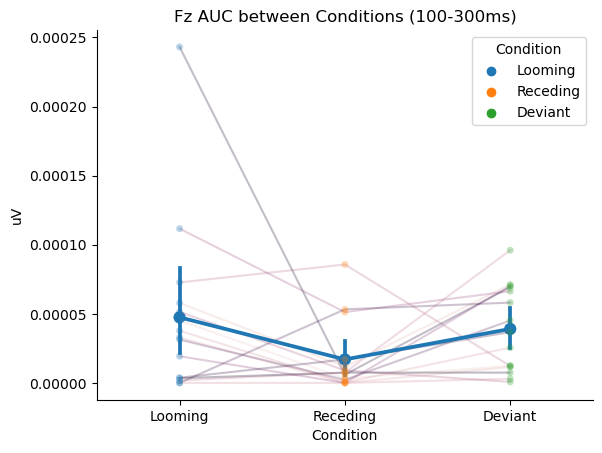

In [33]:
ax = sns.lineplot(x='Condition', y = 'uV', units= "Subject", estimator=None, data = df, alpha=0.3, hue="Subject", legend=False)
sns.stripplot(x="Condition", y="uV", hue="Condition", data=df, jitter=False, alpha =0.3)
ax = sns.pointplot(x='Condition', y = 'uV', data = df)
ax.set_title(f'{ch} {method} between Conditions (100-300ms)')
sns.despine()

In [34]:
# Repeated measure ANOVA
pg.rm_anova(dv='uV', 
               within='Condition', 
               subject="Subject",
               data=df,
               detailed=True)

g:\Utilisateurs\rudradeep.guha\Anaconda3\envs\eelbrain\lib\site-packages\pingouin\parametric.py:551: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  ss_resall = grp_with.apply(lambda x: (x - x.mean()) ** 2).sum()
g:\Utilisateurs\rudradeep.guha\Anaconda3\envs\eelbrain\lib\site-packages\pingouin\distribution.py:977: RuntimeWarning: divide by zero encountered in double_scalars
  W = np.product(eig) / (eig.sum() / d) ** d


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,Condition,7.445708e-09,2,3.722854e-09,2.303404,0.118549,0.087572,0.787304
1,Error,4.525473e-08,28,1.616240e-09,NaN,NaN,NaN,NaN


In [35]:
pg.ttest(x=df[df.Condition=='Looming'].uV, y=df[df.Condition=='Receding'].uV, paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.826877,14,two-sided,0.089112,"[-0.0, 0.0]",0.637352,0.992,0.631974


In [36]:
pg.ttest(x=df[df.Condition=='Looming'].uV, y=df[df.Condition=='Deviant'].uV, paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.517435,14,two-sided,0.612931,"[-0.0, 0.0]",0.170044,0.295,0.094255


In [37]:
pg.ttest(x=df[df.Condition=='Receding'].uV, y=df[df.Condition=='Deviant'].uV, paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.168467,14,two-sided,0.047841,"[-0.0, -0.0]",0.77766,1.59,0.799636
